In [2]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import math

assets_dir = '../Assets/'

In [3]:
def histogram_equalization(img_channel):
    h, w = img_channel.shape
    tot_pixels = h * w
    L = 256

    histogram = cv2.calcHist([img_channel], [0], None, [L], [0, L]).flatten()
    pdf = histogram / tot_pixels
    cdf = np.cumsum(pdf)
    equalized_channel = np.zeros_like(img_channel)
    equalized_channel = cv2.LUT(img_channel, np.floor(cdf * (L - 1)).astype(np.uint8))
    new_histogram = cv2.calcHist([equalized_channel], [0], None, [L], [0, L]).flatten()
    new_pdf = new_histogram / tot_pixels
    new_cdf = np.cumsum(new_pdf)
    return equalized_channel, histogram, pdf, cdf, new_histogram, new_pdf, new_cdf
    

In [4]:
def single_gaussian(x, mu, sigma):
    # p(x) = (1/√(2πσ²)) * e^(-(x-μ)²/(2σ²))
    coefficient = 1.0 / math.sqrt(2 * math.pi * sigma**2)
    exponent = -((x - mu)**2) / (2 * sigma**2)
    return coefficient * math.exp(exponent)

def double_gaussian_pdf(x, mu1, sigma1, mu2, sigma2, w1, w2):
    # p(x) = w1 * N(μ1, σ1²) + w2 * N(μ2, σ2²)
    # where w1 + w2 = 1
    gaussian1 = single_gaussian(x, mu1, sigma1)
    gaussian2 = single_gaussian(x, mu2, sigma2)
    return w1 * gaussian1 + w2 * gaussian2

In [5]:
def generate_target_histogram(L=256, mu1=80, sigma1=20, mu2=180, sigma2=25, w1=0.4, w2=0.6):
    x_values = np.arange(0, L)
    target_pdf = np.zeros(L)

    for i in range(L):
        x = x_values[i]
        gauss1 = single_gaussian(x, mu1, sigma1)
        gauss2 = single_gaussian(x, mu2, sigma2)
        target_pdf[i] = w1 * gauss1 + w2 * gauss2

    target_cdf = np.cumsum(target_pdf)
    
    return target_pdf, target_cdf, x_values

In [6]:
def histogram_matching(img_channel, target_cdf):
    h, w = img_channel.shape
    tot_pixels = h * w
    L = 256
    
    input_histogram = cv2.calcHist([img_channel], [0], None, [L], [0, L]).flatten()
    input_pdf = input_histogram / tot_pixels
    input_cdf = np.cumsum(input_pdf)
    lookup_table = np.zeros(L, dtype=np.uint8)
    
    for input_intensity in range(L):
        input_cdf_value = input_cdf[input_intensity]
        target_intensity = np.argmin(np.abs(target_cdf - input_cdf_value))
        lookup_table[input_intensity] = target_intensity
    
    matched_channel = cv2.LUT(img_channel, lookup_table)

    output_histogram = cv2.calcHist([matched_channel], [0], None, [L], [0, L]).flatten()
    output_pdf = output_histogram / tot_pixels
    output_cdf = np.cumsum(output_pdf)
    
    return matched_channel, input_histogram, input_pdf, input_cdf, output_histogram, output_pdf, output_cdf, lookup_table

In [7]:
input_img = cv2.imread(assets_dir + '/generic/land_3.jpg', cv2.IMREAD_GRAYSCALE)
target_pdf, target_cdf, x_values = generate_target_histogram(L=256, mu1=45, sigma1=15, mu2=185, sigma2=30, w1=0.75, w2=0.25)
matched_img, input_hist, input_pdf, input_cdf, output_hist, output_pdf, output_cdf, lookup_table = histogram_matching(input_img, target_cdf)

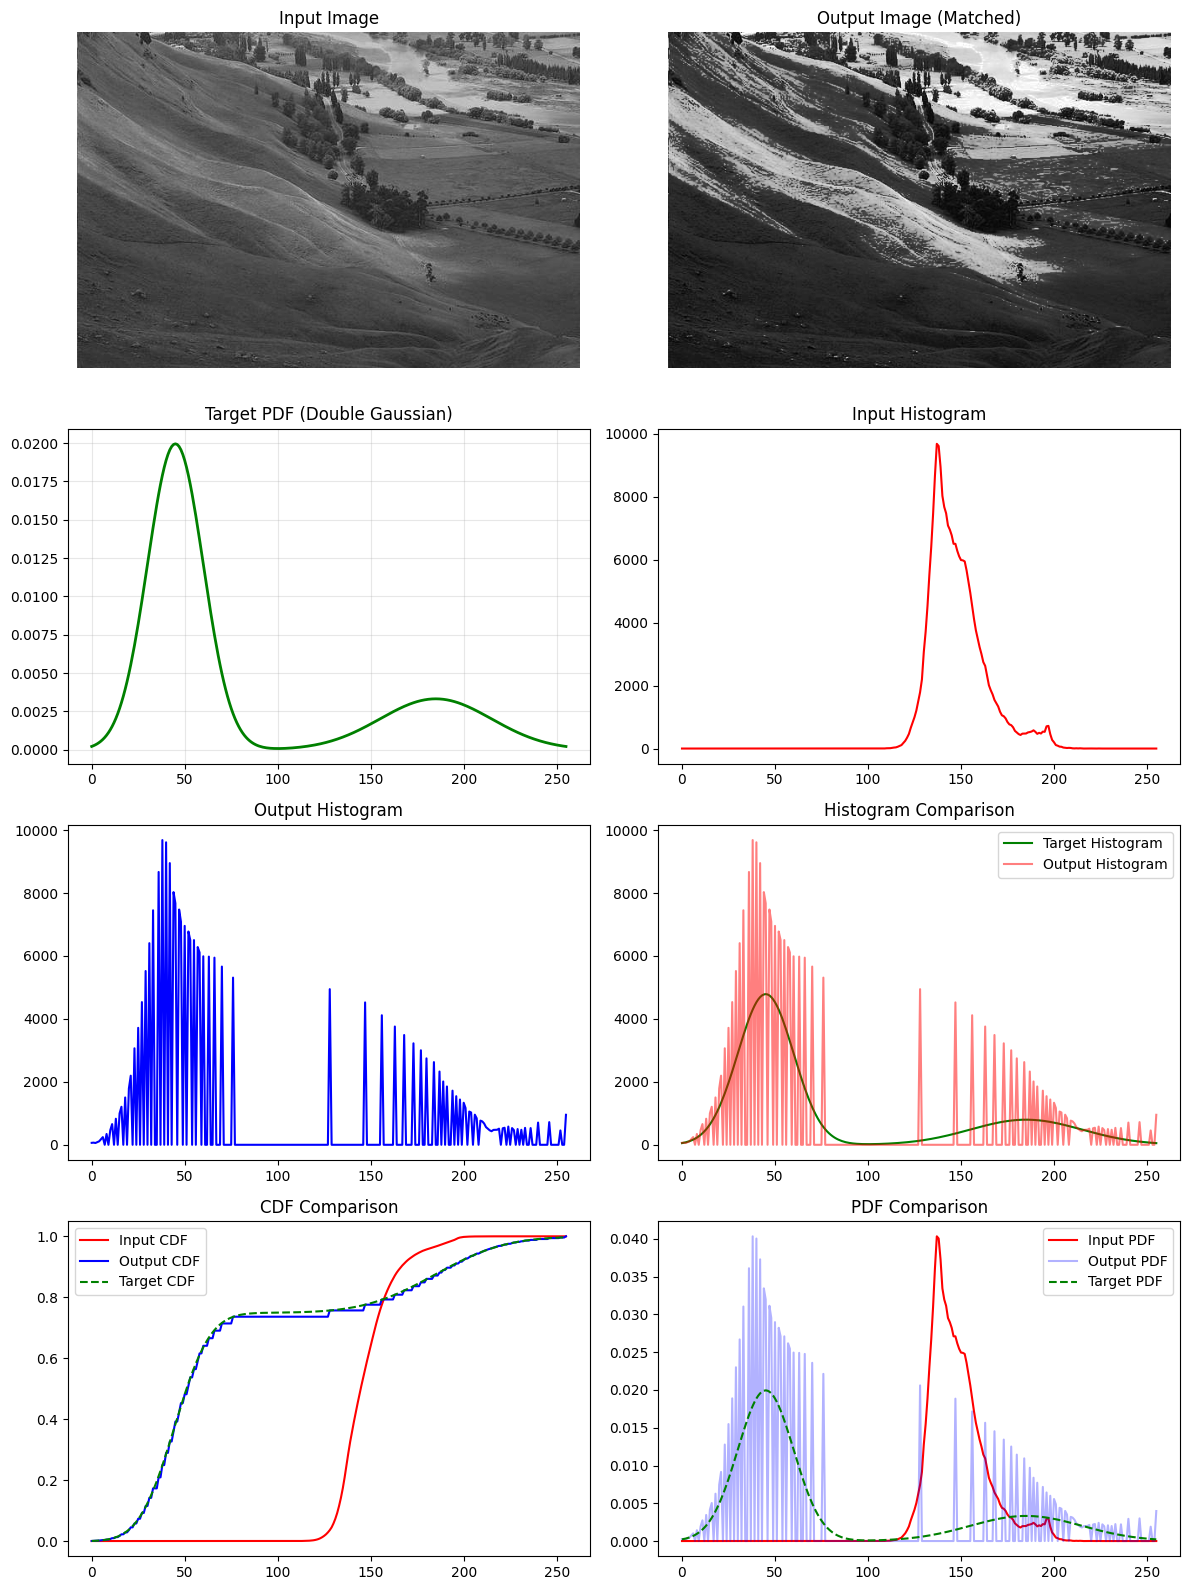

In [8]:
fig, axes = plt.subplots(4, 2, figsize=(12, 16))

# input image
axes[0,0].imshow(input_img, cmap='gray')
axes[0,0].set_title('Input Image')
axes[0,0].axis('off')

# matched image
axes[0,1].imshow(matched_img, cmap='gray')
axes[0,1].set_title('Output Image (Matched)')
axes[0,1].axis('off')

# Target (Double Gaussian)
axes[1,0].plot(x_values, target_pdf, 'g-', linewidth=2)
axes[1,0].set_title('Target PDF (Double Gaussian)')
axes[1,0].grid(True, alpha=0.3)

# Input Histogram
axes[1,1].plot(range(256), input_hist, color='red')
axes[1,1].set_title('Input Histogram')

# Output Histogram
axes[2,0].plot(range(256), output_hist, color='blue')
axes[2,0].set_title('Output Histogram')

# Histogram Comparison
axes[2,1].plot(range(256), target_pdf * input_img.size, color='green', label='Target Histogram')
axes[2,1].plot(range(256), output_hist, color='red', label='Output Histogram', alpha=0.5)
axes[2,1].set_title('Histogram Comparison')
axes[2,1].legend()


# CDF Comparison (before and after)
axes[3,0].plot(range(256), input_cdf, color='red', label='Input CDF')
axes[3,0].plot(range(256), output_cdf, color='blue', label='Output CDF')
axes[3, 0].plot(range(256), target_cdf, color='green', label='Target CDF', linestyle='--')
axes[3,0].set_title('CDF Comparison')
axes[3,0].legend()

# PDF Comparison (before and after)
axes[3,1].plot(range(256), input_pdf, color='red', label='Input PDF')
axes[3,1].plot(range(256), output_pdf, color='blue', label='Output PDF', alpha=0.3)
axes[3,1].plot(range(256), target_pdf, color='green', label='Target PDF', linestyle='--')
axes[3,1].set_title('PDF Comparison')
axes[3,1].legend()

plt.tight_layout()
plt.show()
